In [28]:
import os
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path

In [43]:
INPUT_IMAGES = Path("uk_penguins/images")
INPUT_LABELS = Path("uk_penguins/labels")

OUTPUT_ROOT = Path("uk_penguins_cut")

In [ ]:
TILE_SIZE = 1024
STEP = 768   # overlap ≈20%
VAL_IMAGES = 3

In [31]:
def read_yolo_labels(label_path):
    boxes = []
    if not os.path.exists(label_path):
        return boxes

    with open(label_path) as f:
        for line in f:
            cls, x, y, w, h = map(float, line.split())
            boxes.append((int(cls), x, y, w, h))

    return boxes

In [32]:
def save_yolo_labels(path, boxes):
    with open(path, "w") as f:
        for cls, x, y, w, h in boxes:
            f.write(f"{cls} {x} {y} {w} {h}\n")

In [33]:
def slice_image(img_path, label_path, out_img_dir, out_lbl_dir):

    image = cv2.imread(str(img_path))
    h, w = image.shape[:2]

    labels = read_yolo_labels(label_path)

    abs_boxes = []

    for cls, x, y, bw, bh in labels:

        cx = x * w
        cy = y * h
        bw = bw * w
        bh = bh * h

        x1 = cx - bw / 2
        y1 = cy - bh / 2
        x2 = cx + bw / 2
        y2 = cy + bh / 2

        abs_boxes.append((cls, x1, y1, x2, y2))

    pad_w = max(0, TILE_SIZE - w)
    pad_h = max(0, TILE_SIZE - h)

    if pad_w > 0 or pad_h > 0:
        image = cv2.copyMakeBorder(
            image, 0, pad_h, 0, pad_w,
            cv2.BORDER_CONSTANT,
            value=(0,0,0)
        )
        h, w = image.shape[:2]

    tile_id = 0

    for y in range(0, h - TILE_SIZE + 1, STEP):
        for x in range(0, w - TILE_SIZE + 1, STEP):

            tile = image[y:y+TILE_SIZE, x:x+TILE_SIZE]

            tile_boxes = []

            for cls, bx1, by1, bx2, by2 in abs_boxes:

                ix1 = max(bx1, x)
                iy1 = max(by1, y)
                ix2 = min(bx2, x+TILE_SIZE)
                iy2 = min(by2, y+TILE_SIZE)

                if ix1 < ix2 and iy1 < iy2:

                    bw = ix2 - ix1
                    bh = iy2 - iy1

                    cx = (ix1 + ix2)/2 - x
                    cy = (iy1 + iy2)/2 - y

                    cx /= TILE_SIZE
                    cy /= TILE_SIZE
                    bw /= TILE_SIZE
                    bh /= TILE_SIZE

                    tile_boxes.append((cls,cx,cy,bw,bh))

            if not tile_boxes:
                continue

            name = f"{img_path.stem}_{tile_id}"

            cv2.imwrite(str(out_img_dir / f"{name}.jpg"), tile)

            save_yolo_labels(
                out_lbl_dir / f"{name}.txt",
                tile_boxes
            )

            tile_id += 1


In [37]:
images = list(INPUT_IMAGES.glob("*.jpg"))

In [38]:
images

[PosixPath('uk_penguins/images/0e6f4ec7-C98_GourlayNE_03.jpg'),
 PosixPath('uk_penguins/images/af64c733-C4C5_NorthPoint.jpg'),
 PosixPath('uk_penguins/images/23d3b2e3-C68_GourlaySW2_marked.jpg'),
 PosixPath('uk_penguins/images/42e0323e-C78B_GourlaySW_.jpg'),
 PosixPath('uk_penguins/images/a0d99d4e-C79_GourlayNE.jpg'),
 PosixPath('uk_penguins/images/008b28ca-C83A_GourlayNE.jpg'),
 PosixPath('uk_penguins/images/418ec585-CGrave_GourlayNE_04.jpg'),
 PosixPath('uk_penguins/images/ef936ce5-C63-2_GourlaySW.jpg'),
 PosixPath('uk_penguins/images/5dc4ae26-C101_GourlayNE_083.jpg'),
 PosixPath('uk_penguins/images/b81177d5-CGrave_GourlayNE_01.jpg'),
 PosixPath('uk_penguins/images/15169ef2-C98_GourlayNE_02.jpg'),
 PosixPath('uk_penguins/images/073eb72d-C15_Moyse_20171218_0004.jpg'),
 PosixPath('uk_penguins/images/42f68192-C98_GourlayNE_01.jpg'),
 PosixPath('uk_penguins/images/93b849a5-C80_GourlayNE_VERT_Stitch.jpg'),
 PosixPath('uk_penguins/images/b496f858-C67_GourlaySW.jpg'),
 PosixPath('uk_penguin

In [39]:
val_images = random.sample(images, VAL_IMAGES)

In [40]:
train_images = [i for i in images if i not in val_images]

In [44]:
for split in ["train","val"]:

    (OUTPUT_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)


In [ ]:
for img in train_images:

    label = INPUT_LABELS / f"{img.stem}.txt"

    slice_image(
        img,
        label,
        OUTPUT_ROOT / "images" / "train",
        OUTPUT_ROOT / "labels" / "train"
    )

In [ ]:
for img in val_images:

    label = INPUT_LABELS / f"{img.stem}.txt"

    slice_image(
        img,
        label,
        OUTPUT_ROOT / "images" / "val",
        OUTPUT_ROOT / "labels" / "val"
    )

print("done")

done


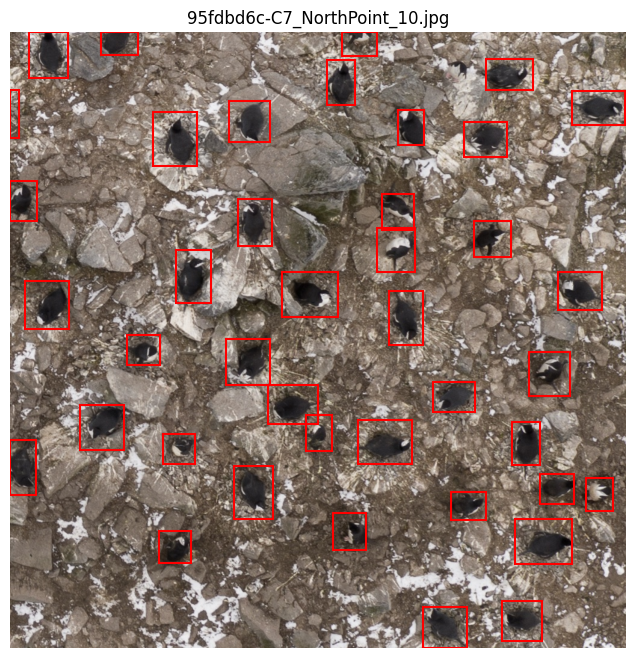

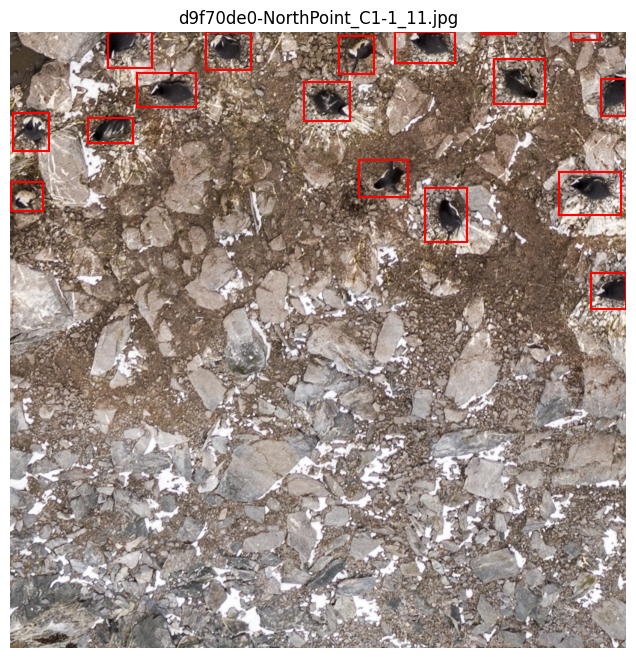

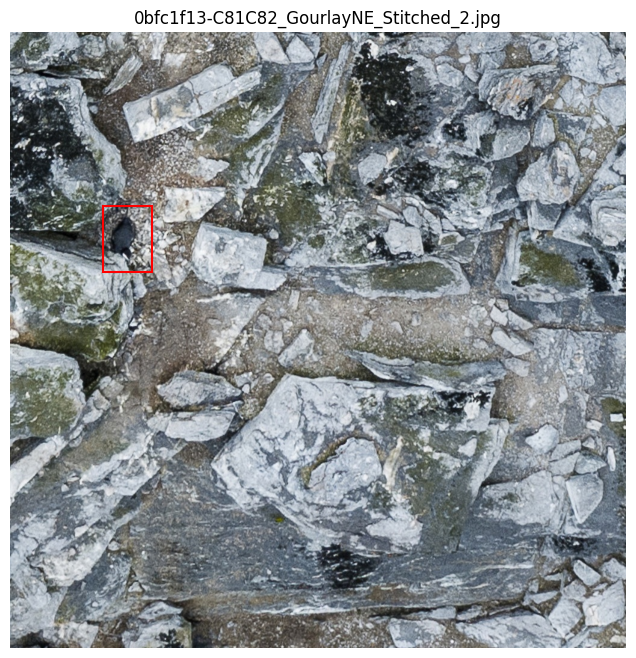

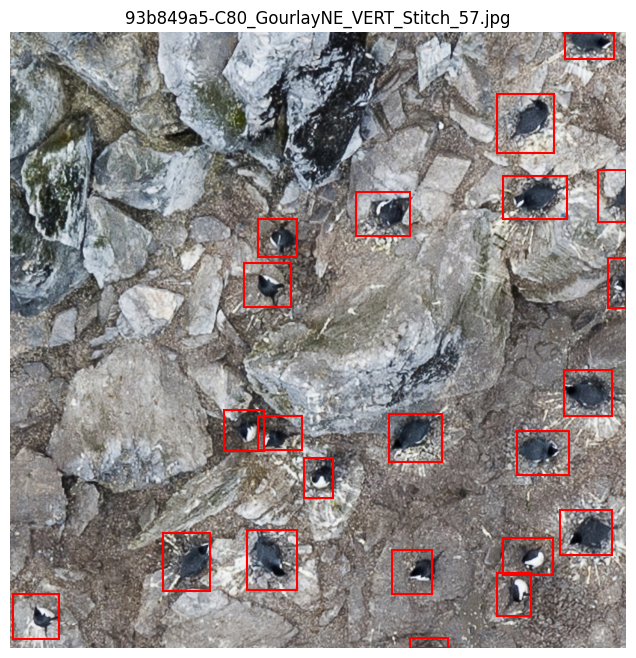

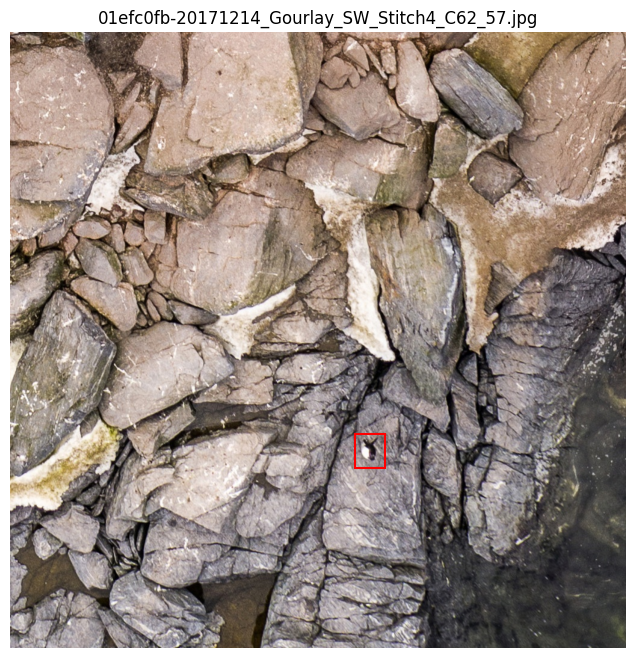

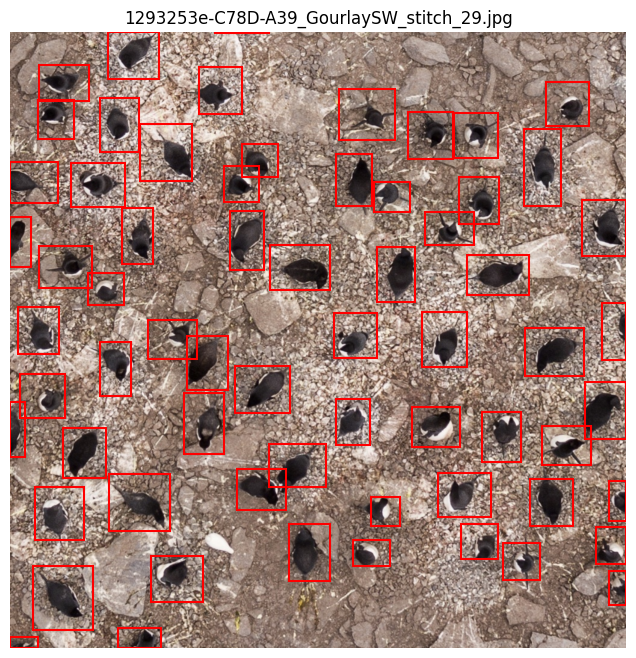

In [ ]:
def show_random_tiles(dataset_root, split="train", num_samples=4):
    img_dir = Path(dataset_root) / "images" / split
    lbl_dir = Path(dataset_root) / "labels" / split

    images = list(img_dir.glob("*.jpg"))
    samples = random.sample(images, min(num_samples, len(images)))

    for img_path in samples:
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        fig, ax = plt.subplots(1, figsize=(8, 8))
        ax.imshow(img)

        label_path = lbl_dir / f"{img_path.stem}.txt"

        if label_path.exists():
            for line in label_path.read_text().strip().splitlines():
                c, x, y, w, h = line.split()
                x, y, w, h = map(float, (x, y, w, h))

                bw = w * W
                bh = h * H
                cx = x * W
                cy = y * H

                x1 = cx - bw / 2
                y1 = cy - bh / 2

                rect = patches.Rectangle(
                    (x1, y1), bw, bh,
                    linewidth=1.5,
                    edgecolor='red',
                    facecolor='none'
                )
                ax.add_patch(rect)

        ax.set_title(img_path.name)
        ax.axis("off")
        plt.show()


show_random_tiles("uk_penguins_cut", split="train", num_samples=6)

In [48]:
splits = ["train", "val"]

for split in splits:

    img_dir = OUTPUT_ROOT / "images" / split
    lbl_dir = OUTPUT_ROOT / "labels" / split

    empty = 0
    total = 0

    for img in img_dir.glob("*.*"):

        total += 1

        label = lbl_dir / f"{img.stem}.txt"

        if not label.exists() or label.read_text().strip() == "":
            empty += 1

    print(f"{split}: {empty} images without boxes out of {total}")

train: 0 images without boxes out of 589
val: 0 images without boxes out of 28
